# EV_LEAD_SALES_ANALYSIS 

## Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# better visuals 
sns.set(style = "whitegrid")

## Load Data

In [3]:
file_path = "EV_Lead_sales_data.xlsx"
df = pd.read_excel(file_path)

df.head()

,Lead ID,Store Name,Lead Type,Lead Date,Pre-Booking Date,Booking Date,Delivery Date,Cancellation Status,Cancellation Reason,Service Follow-up Date,TAT Pre-Booking (Days),TAT Booking (Days),TAT Delivery (Days),Customer Rating
0,L1000,Bangalore MBC,Warm,2025-10-21,2025-10-25,2025-10-29,2025-11-03,No,NaN,2025-11-28,4.0,4.0,5.0,2.0
1,L1003,Bangalore MBC,Cold,2025-10-28,NaT,NaT,NaT,Yes,Model Unavailable,NaT,NaN,NaN,NaN,NaN
2,L1008,Bangalore MBC,Hot,2025-10-14,2025-10-17,2025-10-20,2025-10-25,No,NaN,2025-11-05,3.0,3.0,5.0,8.0
3,L1010,Bangalore MBC,Cold,2025-10-12,NaT,NaT,NaT,Yes,Other,NaT,NaN,NaN,NaN,NaN
4,L1017,Bangalore MBC,Hot,2025-10-14,2025-10-15,2025-10-18,2025-10-23,No,NaN,2025-11-18,1.0,3.0,5.0,0.0


## Clean Data

In [4]:
# standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")

# check missing values
df.isnull().sum()

lead_id                     0
store_name                  0
lead_type                   0
lead_date                   0
pre-booking_date          188
booking_date              188
delivery_date             188
cancellation_status         0
cancellation_reason       729
service_follow-up_date    271
tat_pre-booking_(days)    188
tat_booking_(days)        188
tat_delivery_(days)       188
customer_rating           271
dtype: int64

## cancellation reason

In [5]:
df["cancellation_reason"] = df["cancellation_reason"].fillna("Not Cancelled")

## Covert Dates

In [8]:
date_cols = ["lead_date", "pre_booking_date", "booking_date", "delivery_date"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Feature Engineering
## Create funnel flags

In [9]:
df["is_prebooked"] = df["pre-booking_date"].notna().astype(int)
df["is_booked"] = df["booking_date"].notna().astype(int)
df["is_delivered"] = df["delivery_date"].notna().astype(int)
df["service_followup_done"] = df["service_follow-up_date"].notna().astype(int)

## Calculate TAT (Turnaround Time)

In [12]:
df["tat_lead_to_prebook"] = (df["pre-booking_date"] - df["lead_date"]).dt.days
df["tat_prebook_to_book"] = (df["booking_date"] - df["pre-booking_date"]).dt.days
df["tat_book_to_delivery"] = (df["delivery_date"] - df["booking_date"]).dt.days

## Lead Conversion Funnel (by store)

In [16]:
# Groups the date store-wise, then calculate totals
funnel = df.groupby("store_name").agg({
    "lead_id": "count",                     #tot leads per store
    "is_prebooked": "sum",                  #how many leads reached pre-booking
    "is_booked": "sum",                     #how many got booked
    "is_delivered": "sum"                   #how many got delivered 
}).reset_index()

funnel.columns = ["store", "leads", "prebooked", "booked", "delivered"]

## Plot (stacked bar)

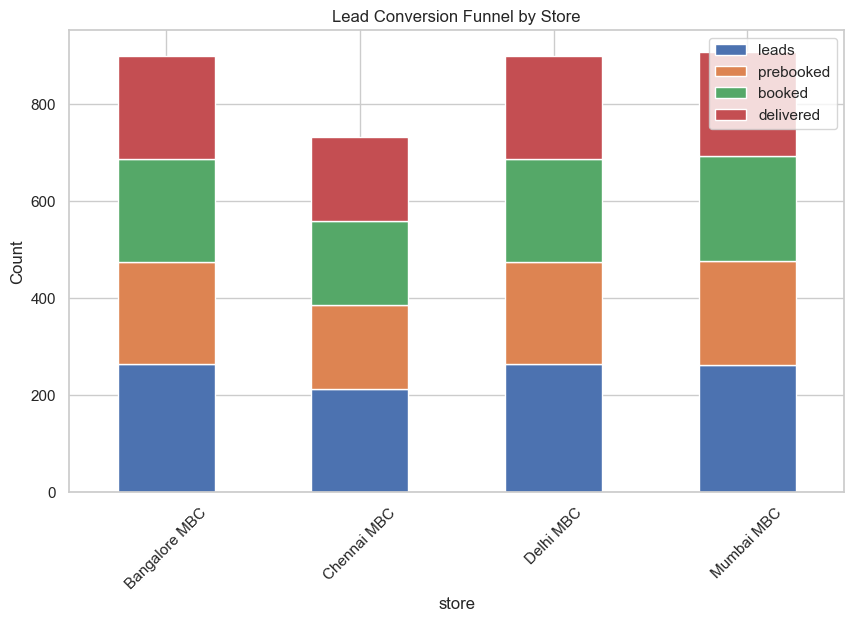

In [18]:
funnel.set_index("store").plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Lead Conversion Funnel by Store")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## TAT Performance (Grouped Bar)

In [21]:
# calculates the avg turnaround time (TAT) for each stage of the process per store
tat = df.groupby("store_name")[[
    "tat_lead_to_prebook",
    "tat_prebook_to_book",
    "tat_book_to_delivery"
]].mean().reset_index()

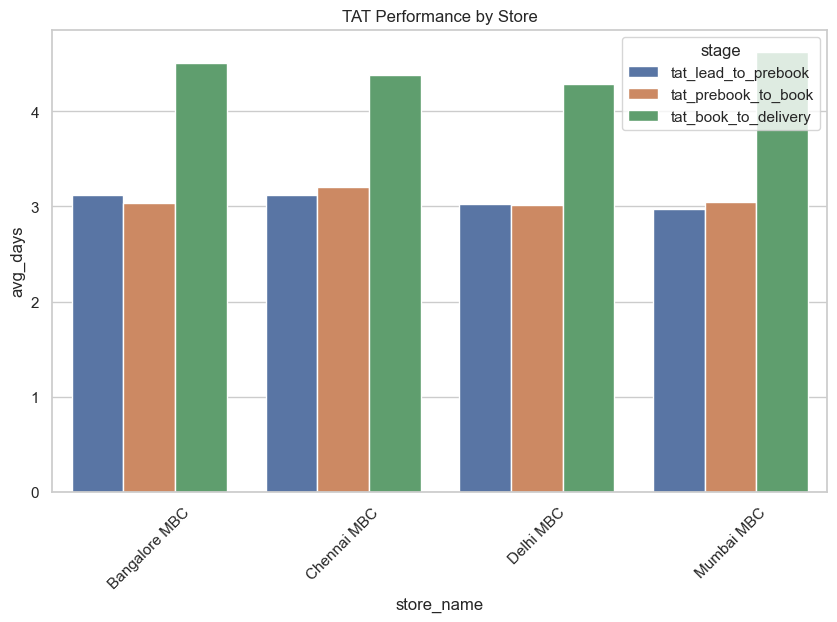

In [23]:
# compares how long each store takes at different stages
tat_melted = tat.melt(id_vars="store_name", var_name="stage", value_name="avg_days")

plt.figure(figsize=(10,6))
sns.barplot(data=tat_melted, x="store_name", y="avg_days", hue="stage")
plt.title("TAT Performance by Store")
plt.xticks(rotation=45)
plt.show()

## Cancellation Reseans

In [29]:
cancel_df = df[df["cancellation_reason"] != "Unknown"]             # filters only cancelled cases

# Groups data by storw and cancellation reason to count how many times each resaon occurs.
cancel_group = cancel_df.groupby(["store_name", "cancellation_reason"]).size().reset_index(name="count")

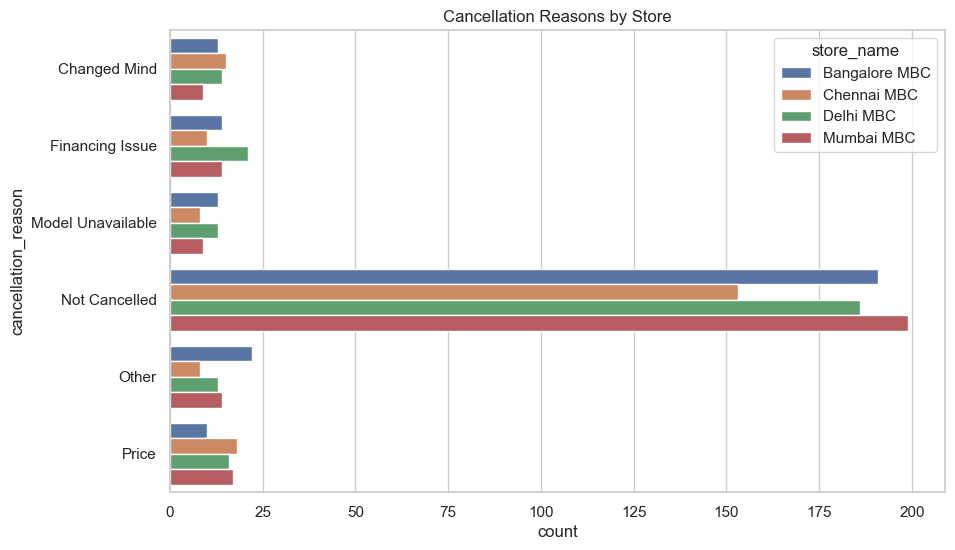

In [28]:
# for comparing cancellation reasons accros stores 
plt.figure(figsize=(10,6))
sns.barplot(data=cancel_group, y="cancellation_reason", x="count", hue="store_name")
plt.title("Cancellation Reasons by Store")
plt.show()

## Hot/ Warm/ Cold Distribution 

In [31]:
lead_dist = df.groupby(["store_name", "lead_type"]).size().reset_index(name="count")

# Convert to percentage
lead_dist["percentage"] = lead_dist.groupby("store_name")["count"].transform(lambda x: x/x.sum())

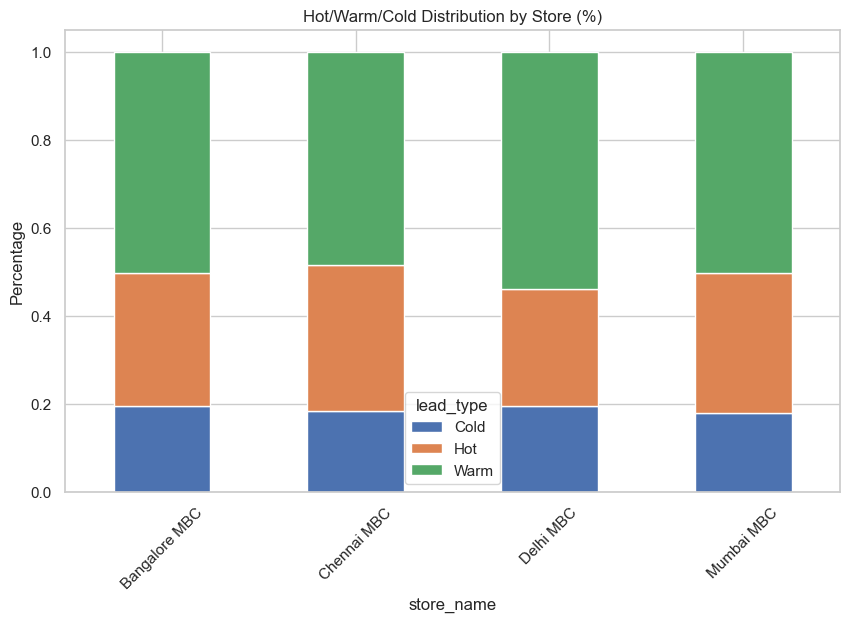

In [33]:
pivot = lead_dist.pivot(index="store_name", columns="lead_type", values="percentage")

pivot.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Hot/Warm/Cold Distribution by Store (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

## Customer Rating Distribution

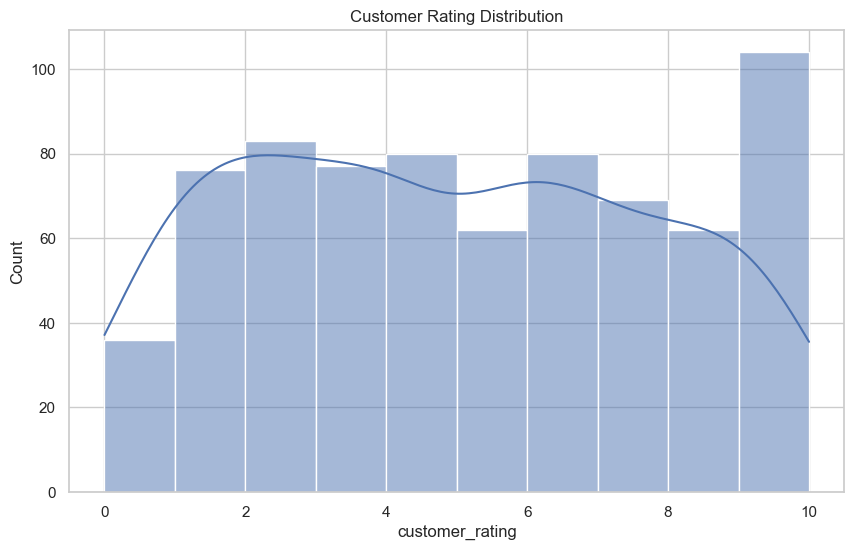

In [34]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="customer_rating", bins=10, kde=True)
plt.title("Customer Rating Distribution")
plt.show()

## Conversion Rate% 

In [37]:
# calculates conversion rates b/t ea stage of funnel for every store 
funnel["prebook_rate"] = funnel["prebooked"] / funnel["leads"]
funnel["booking_rate"] = funnel["booked"] / funnel["prebooked"].replace(0, np.nan)
funnel["delivery_rate"] = funnel["delivered"] / funnel["booked"].replace(0, np.nan)

funnel

,store,leads,prebooked,booked,delivered,prebook_rate,booking_rate,delivery_rate
0,Bangalore MBC,263,212,212,212,0.806084,1.0,1.0
1,Chennai MBC,212,173,173,173,0.816038,1.0,1.0
2,Delhi MBC,263,212,212,212,0.806084,1.0,1.0
3,Mumbai MBC,262,215,215,215,0.820611,1.0,1.0


In [49]:
# All Hot leads have already been converted into bookings,
# indicating strong conversion efficiency for high-intent customers.
high_potential = df[
    (df["lead_type"] == "Hot") & 
    (df["is_booked"] == 0)
]

high_potential.head()

,lead_id,store_name,lead_type,lead_date,pre-booking_date,booking_date,delivery_date,cancellation_status,cancellation_reason,service_follow-up_date,...,tat_booking_(days),tat_delivery_(days),customer_rating,is_prebooked,is_booked,is_delivered,service_followup_done,tat_lead_to_prebook,tat_prebook_to_book,tat_book_to_delivery


In [52]:
# counts how many records fall under each category (Hot, Warm, Cold).
df["lead_type"].value_counts()

lead_type
Warm    509
Hot     303
Cold    188
Name: count, dtype: int64

In [53]:
# If is_booked = 1 for all Hot leads → result will still be 0
# That means all Hot leads are already converted
df["is_booked"].value_counts()

is_booked
1    812
0    188
Name: count, dtype: int64

## Store Performance summary

In [57]:
# This groups data by store to calculate total leads, total deliveries, 
# and average customer rating for each store.

summary = df.groupby("store_name").agg({
    "lead_id": "count",
    "is_delivered": "sum",
    "customer_rating": "mean"
}).rename(columns={
    "lead_id": "total_leads",
    "is_delivered": "deliveries",
    "customer_rating": "avg_rating"
})

# overall conversion rate (deliveries ÷ total leads) to evaluate store performance.
summary["conversion_rate"] = summary["deliveries"] / summary["total_leads"]
summary

,total_leads,deliveries,avg_rating,conversion_rate
store_name,,,,
Bangalore MBC,263,212,4.670157,0.806084
Chennai MBC,212,173,5.013072,0.816038
Delhi MBC,263,212,4.897849,0.806084
Mumbai MBC,262,215,4.854271,0.820611


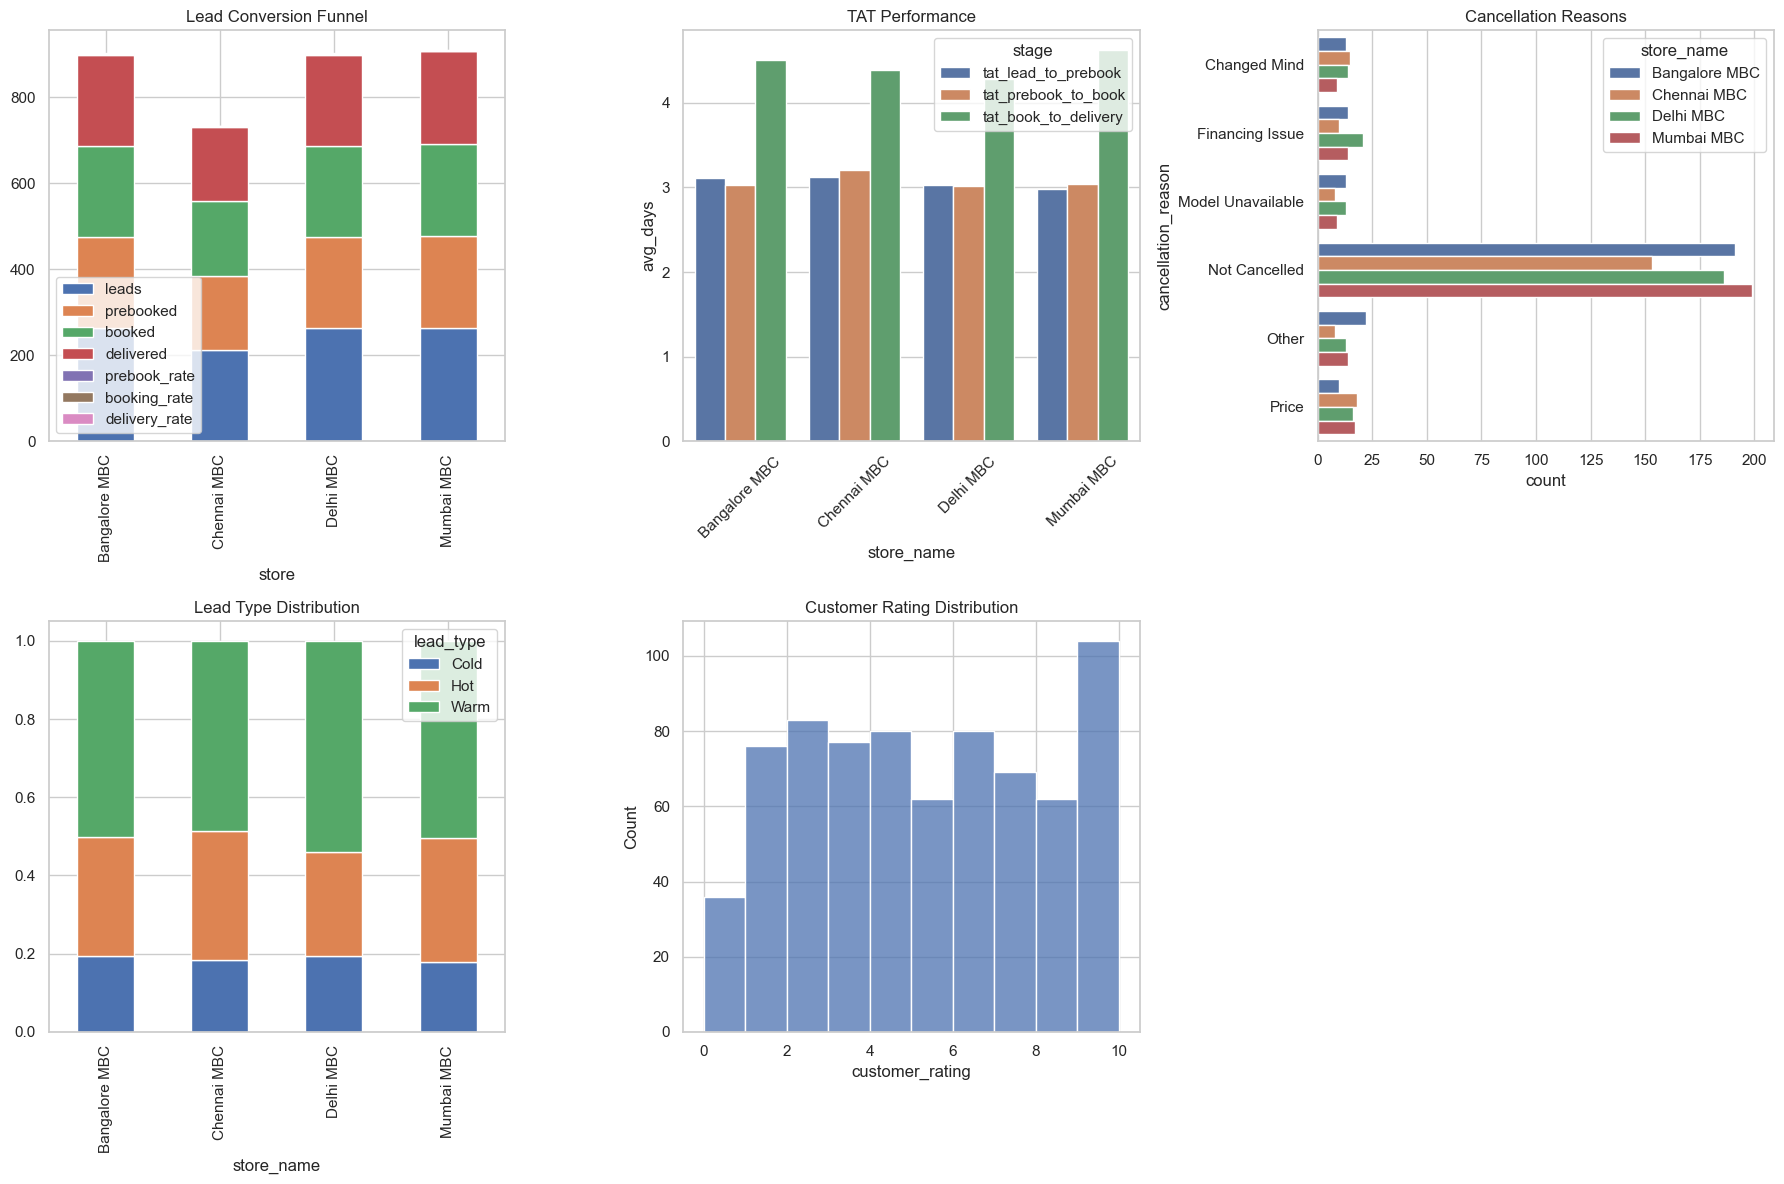

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,12))

# 1. Funnel Chart
plt.subplot(2,3,1)
funnel.set_index("store").plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Lead Conversion Funnel")

# 2. TAT Performance
plt.subplot(2,3,2)
sns.barplot(data=tat_melted, x="store_name", y="avg_days", hue="stage")
plt.title("TAT Performance")
plt.xticks(rotation=45)

# 3. Cancellation Reasons
plt.subplot(2,3,3)
sns.barplot(data=cancel_group, y="cancellation_reason", x="count", hue="store_name")
plt.title("Cancellation Reasons")

# 4. Lead Distribution
plt.subplot(2,3,4)
pivot.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Lead Type Distribution")

# 5. Customer Ratings
plt.subplot(2,3,5)
sns.histplot(data=df, x="customer_rating", bins=10)
plt.title("Customer Rating Distribution")

plt.tight_layout()
plt.show()

# KEY INSIGHTS

# PROBLEM AREAS

# RECOMMENDATIONS 

## The business shows strong conversion performance, but improvements in delivery timelines, financing support, and customer experience can significantly enhance overall efficiency and satisfaction.